In [1]:
# ============================================================================
# REPRODUCIBILITY SETUP - MUST BE AT THE TOP BEFORE IMPORTS
# ============================================================================
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
import numpy as np
import tensorflow as tf

def set_global_seeds(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
    # For PyTorch (TabNet)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

# Call immediately
set_global_seeds(42)

# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, average_precision_score, cohen_kappa_score,
                            balanced_accuracy_score, matthews_corrcoef, brier_score_loss)
from imblearn.over_sampling import SMOTE

# Traditional ML
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              VotingClassifier, AdaBoostClassifier,
                              HistGradientBoostingClassifier)
from sklearn.svm import SVC

# Gradient Boosting
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Deep Learning - Keras
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, 
                                     Input, Concatenate, LeakyReLU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

import warnings
warnings.filterwarnings('ignore')


In [2]:


# # 3. SET GLOBAL SEEDS
# def set_global_seeds(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)
#     tf.keras.utils.set_random_seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# set_global_seeds(42)

# Models

In [3]:

# ============================================================================
# DATA PREPARATION
# ============================================================================
print("="*80)
print("COMPREHENSIVE MODEL COMPARISON - MALNUTRITION PREDICTION")
print("="*80)

# Load data
df = pd.read_csv(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Dataset\data.csv')
X = df.drop(columns=['malnutrition'])
y = df['malnutrition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nOriginal Data:")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Features: {X.shape[1]}")
print(f"\nOriginal class distribution (train):")
print(y_train.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training samples: {len(X_train_balanced)}")
print(f"\nBalanced class distribution:")
print(y_train_balanced.value_counts())

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def evaluate_model(y_true, y_pred, y_pred_proba=None):
    """Calculate all evaluation metrics"""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Balanced_Acc': balanced_accuracy_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Cohen Kappa': cohen_kappa_score(y_true, y_pred)
    }
    
    if y_pred_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_pred_proba)
        metrics['Avg_Precision'] = average_precision_score(y_true, y_pred_proba)
        metrics['Brier'] = brier_score_loss(y_true, y_pred_proba)
    else:
        metrics['ROC-AUC'] = None
        metrics['Avg_Precision'] = None
        metrics['Brier'] = None
    
    return metrics

# ============================================================================
# KERAS F1 METRIC
# ============================================================================
class F1Score(keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = keras.metrics.Precision()
        self.recall = keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * (p * r) / (p + r + keras.backend.epsilon())

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

# ============================================================================
# STEP 2: TRADITIONAL ML MODELS
# ============================================================================
print("\n" + "="*80)
print("TRAINING TRADITIONAL ML MODELS")
print("="*80)

traditional_models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'scaled': True
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'scaled': True
    },
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42, max_depth=10),
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15, 
                                       min_samples_split=5, n_jobs=-1),
        'scaled': False
    },
    'Extra Trees': {
        'model': ExtraTreesClassifier(n_estimators=300, max_depth=20, min_samples_split=4, min_samples_leaf=2, 
                                      max_features='sqrt', bootstrap=True, random_state=42, n_jobs=-1
        ),
        'scaled': False
    # 'Extra Trees': {
    #     'model': ExtraTreesClassifier(n_estimators=200, max_depth=15, min_samples_split=5,
    #                                   random_state=42, n_jobs=-1),
    #     'scaled': False
    },
    'SVM': {
        'model': SVC(kernel='rbf', probability=True, random_state=42),
        'scaled': True
    }
}

all_results = []

for name, config in traditional_models.items():
    print(f"Training {name}...", end=" ")
    model = config['model']
    
    # Use balanced data
    if config['scaled']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train_balanced
        X_te = X_test
    
    try:
        model.fit(X_tr, y_train_balanced)
        y_pred = model.predict(X_te)
        y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        metrics['Model'] = name
        metrics['Category'] = 'Traditional ML'
        all_results.append(metrics)
        print("✓")
    except Exception as e:
        print(f"✗ Error: {str(e)}")

# ============================================================================
# STEP 3: GRADIENT BOOSTING MODELS
# ============================================================================
print("\n" + "="*80)
print("TRAINING GRADIENT BOOSTING MODELS")
print("="*80)

boosting_models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', n_jobs=-1
    ),
     'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, 
        max_depth=7, 
        learning_rate=0.05,
        num_leaves=50, 
        subsample=0.8, 
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1, 
        reg_lambda=0.1, 
        random_state=42, 
        verbose=-1, 
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.05,
        l2_leaf_reg=3, subsample=0.8, random_state=42, verbose=0
    ),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=7, learning_rate=0.05,
        l2_regularization=1.0, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=200, learning_rate=0.1, 
        algorithm='SAMME', random_state=42
    )
}

for name, model in boosting_models.items():
    print(f"Training {name}...", end=" ")
    try:
        model.fit(X_train_balanced, y_train_balanced)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        metrics['Model'] = name
        metrics['Category'] = 'Gradient Boosting'
        all_results.append(metrics)
        print("✓")
    except Exception as e:
        print(f"✗ Error: {str(e)}")

# ============================================================================
# STEP 4: TABNET
# ============================================================================
print("\n" + "="*80)
print("TRAINING TABNET")
print("="*80)

try:
    X_train_np = X_train_balanced.values.astype(np.float32)
    X_test_np = X_test.values.astype(np.float32)
    y_train_np = y_train_balanced.values.astype(np.int64)
    y_test_np = y_test.values.astype(np.int64)
    
    tabnet = TabNetClassifier(
        n_d=64, n_a=64, n_steps=5, gamma=1.5, lambda_sparse=1e-4,
        momentum=0.02,
        clip_value=2.0,
        optimizer_fn=torch.optim.Adam, 
        optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
        scheduler_params={"step_size": 50, "gamma": 0.95},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='sparsemax', seed=42, verbose=0
    )
    
    print("Training TabNet...", end=" ")
    tabnet.fit(
        X_train=X_train_np, y_train=y_train_np,
        eval_set=[(X_test_np, y_test_np)], 
        eval_name=['test'],
        eval_metric=['accuracy'], 
        max_epochs=200, patience=50,
        batch_size=1024, virtual_batch_size=256, 
        num_workers=0, drop_last=False
    )
    
    y_pred = tabnet.predict(X_test_np)
    y_pred_proba = tabnet.predict_proba(X_test_np)[:, 1]
    
    metrics = evaluate_model(y_test_np, y_pred, y_pred_proba)
    metrics['Model'] = 'TabNet'
    metrics['Category'] = 'Deep Learning'
    all_results.append(metrics)
    print("✓")
except Exception as e:
    print(f"✗ Error: {str(e)}")

# ============================================================================
# STEP 5: KERAS DEEP LEARNING MODELS - FULLY REPRODUCIBLE
# ============================================================================
print("\n" + "="*80)
print("TRAINING KERAS DEEP LEARNING MODELS")
print("="*80)

# Prepare data
X_train_tf = X_train_scaled.astype(np.float32)
X_test_tf = X_test_scaled.astype(np.float32)
y_train_tf = y_train_balanced.values.astype(np.int32)
y_test_tf = y_test.values.astype(np.int32)

input_dim = X_train_tf.shape[1]

# KERAS MODEL DEFINITIONS
def create_dnn(input_dim, seed=42):
    """Deep Neural Network with reproducibility"""
    # Set seeds before model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed)),
        BatchNormalization(),
        LeakyReLU(0.1),
        Dropout(0.3, seed=seed),
        
        Dense(128, kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed)),
        BatchNormalization(),
        LeakyReLU(0.1),
        Dropout(0.3, seed=seed),
        
        Dense(64, kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed)),
        BatchNormalization(),
        LeakyReLU(0.1),
        Dropout(0.2, seed=seed),
        
        Dense(1, activation='sigmoid',
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', F1Score()]
    )
    return model


def residual_block(x, units, drop=0.3, seed=42):
    """Residual block with reproducible initialization"""
    fx = Dense(units, kernel_regularizer=regularizers.l2(0.001),
               kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(x)
    fx = BatchNormalization()(fx)
    fx = LeakyReLU(0.1)(fx)
    fx = Dropout(drop, seed=seed)(fx)
    
    fx = Dense(units, kernel_regularizer=regularizers.l2(0.001),
               kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+1))(fx)
    fx = BatchNormalization()(fx)
    
    # Match dimensions if needed
    if x.shape[-1] != units:
        x = Dense(units, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+2))(x)
    
    return LeakyReLU(0.1)(layers.Add()([fx, x]))


def create_resnet(input_dim, seed=42):
    """ResNet-style model with reproducibility"""
    # Set seeds before model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    inputs = Input(shape=(input_dim,))
    
    x = Dense(128, kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed))(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.3, seed=seed)(x)
    
    x = residual_block(x, 128, 0.3, seed=seed+10)
    x = residual_block(x, 64, 0.2, seed=seed+20)
    
    outputs = Dense(1, activation='sigmoid',
                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+30))(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', F1Score()]
    )
    return model


def create_wide_deep(input_dim, seed=42):
    """Enhanced Wide & Deep model with better performance"""
    # Set seeds before model creation
    tf.random.set_seed(seed)
    np.random.seed(seed)
    
    inputs = Input(shape=(input_dim,))
    
    # WIDE PATH 
    # Wider path to capture more linear patterns
    wide = Dense(128, activation='relu',  # Increased from 32 to 128
                 kernel_regularizer=regularizers.l2(0.0005),  # Added regularization
                 kernel_initializer=tf.keras.initializers.HeNormal(seed=seed))(inputs)
    wide = BatchNormalization()(wide)  # Added batch norm
    wide = Dropout(0.25, seed=seed)(wide)  # Added dropout
    
    # Additional wide layer for better feature extraction
    wide = Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.0005),
                 kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+1))(wide)
    wide = BatchNormalization()(wide)
    
    # Deeper and wider network
    deep = Dense(384, kernel_regularizer=regularizers.l2(0.001),  # Increased from 256 to 384
                 kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+10))(inputs)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(0.1)(deep)
    deep = Dropout(0.4, seed=seed+10)(deep)  # Increased dropout
    
    deep = Dense(192, kernel_regularizer=regularizers.l2(0.001),  # Increased from 128 to 192
                 kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+11))(deep)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(0.1)(deep)
    deep = Dropout(0.35, seed=seed+11)(deep)
    
    # Additional deep layer for more complexity
    deep = Dense(96, kernel_regularizer=regularizers.l2(0.001),  # Added layer
                 kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+12))(deep)
    deep = BatchNormalization()(deep)
    deep = LeakyReLU(0.1)(deep)
    deep = Dropout(0.3, seed=seed+12)(deep)
    
    # COMBINE WIDE & DEEP PATHS
    combined = Concatenate()([wide, deep])
    
    # Enhanced joint representation layers
    x = Dense(128, activation='relu',  # Increased from 32 to 128
              kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+20))(combined)
    x = BatchNormalization()(x)
    x = Dropout(0.3, seed=seed+20)(x)
    
    # Additional joint layer
    x = Dense(64, activation='relu',  # Added layer
              kernel_regularizer=regularizers.l2(0.001),
              kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+21))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25, seed=seed+21)(x)
    
    # Final dense layer before output
    x = Dense(32, activation='relu',  # Added layer
              kernel_regularizer=regularizers.l2(0.0005),
              kernel_initializer=tf.keras.initializers.HeNormal(seed=seed+22))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2, seed=seed+22)(x)
    
    # OUTPUT LAYER
    outputs = Dense(1, activation='sigmoid',
                    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed+30))(x)
    
    model = Model(inputs, outputs)
    
    # Use AdamW for better regularization or standard Adam with tuned LR
    model.compile(
        optimizer=Adam(learning_rate=0.001),  # Increased from 0.0005 to 0.001
        loss='binary_crossentropy',
        metrics=['accuracy', F1Score()]
    )
    
    return model


# ============================================================================
# TRAIN KERAS MODELS WITH FULL REPRODUCIBILITY
# ============================================================================

keras_model_configs = {
    'DNN (Keras)': {'create_fn': create_dnn, 'seed': 42},
    'ResNet (Keras)': {'create_fn': create_resnet, 'seed': 43},
    'Wide & Deep (Keras)': {'create_fn': create_wide_deep, 'seed': 44}
}

for name, config in keras_model_configs.items():
    print(f"Training {name}...", end=" ")
    
    try:
        # CRITICAL: Set all seeds before each model
        seed = config['seed']
        tf.random.set_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        
        # Create model
        model = config['create_fn'](input_dim, seed=seed)
        
        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_f1_score', 
                mode='max', 
                patience=20, 
                restore_best_weights=True,
                verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_f1_score', 
                mode='max', 
                patience=8, 
                factor=0.5, 
                min_lr=1e-7,
                verbose=0
            )
        ]
        
        # Train with fixed seed
        history = model.fit(
            X_train_tf, y_train_tf, 
            validation_split=0.2,
            epochs=100,
            batch_size=64,
            callbacks=callbacks,
            verbose=0,
            shuffle=True  # Shuffling is controlled by seed
        )
        
        # Predict
        y_pred_proba = model.predict(X_test_tf, verbose=0).flatten()
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Evaluate
        metrics = evaluate_model(y_test_tf, y_pred, y_pred_proba)
        metrics['Model'] = name
        metrics['Category'] = 'Deep Learning'
        all_results.append(metrics)
        
        # Optional: Store training history
        metrics['best_epoch'] = len(history.history['loss']) - callbacks[0].patience
        
        print("✓")
        
        # Clear session to free memory
        keras.backend.clear_session()
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*80)

final_df = pd.DataFrame(all_results)
final_df = final_df.sort_values('F1-Score', ascending=False)

display_cols = ['Model', 'Category', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 
                'Avg_Precision', 'Balanced_Acc', 'Cohen Kappa', 'MCC', 'Brier']                

print("\nAll Models Ranked by F1-Score:")
print("="*80)

print(final_df[display_cols].round(2).to_string(index=False))

print("\n" + "="*80)
print(f"   BEST MODEL: {final_df.iloc[0]['Model']}")
print(f"   Category: {final_df.iloc[0]['Category']}")
print(f"   Accuracy: {final_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1-Score: {final_df.iloc[0]['F1-Score']:.4f}")
print(f"   ROC-AUC: {final_df.iloc[0]['ROC-AUC']:.4f}")
print("="*80)

# Save results
final_df.to_csv('complete_model_comparison.csv', index=False)
print("\nResults saved to 'complete_model_comparison.csv'")

COMPREHENSIVE MODEL COMPARISON - MALNUTRITION PREDICTION

Original Data:
  Training samples: 5132
  Test samples: 1284
  Features: 16

Original class distribution (train):
malnutrition
0    2936
1    2196
Name: count, dtype: int64

After SMOTE:
  Training samples: 5872

Balanced class distribution:
malnutrition
0    2936
1    2936
Name: count, dtype: int64

TRAINING TRADITIONAL ML MODELS
Training Logistic Regression... ✓
Training KNN... ✓
Training LDA... ✓
Training Decision Tree... ✓
Training Random Forest... ✓
Training Extra Trees... ✓
Training SVM... ✓

TRAINING GRADIENT BOOSTING MODELS
Training XGBoost... ✓
Training LightGBM... ✓
Training CatBoost... ✓
Training Hist Gradient Boosting... ✓
Training AdaBoost... ✓

TRAINING TABNET
Training TabNet... 
Early stopping occurred at epoch 162 with best_epoch = 112 and best_test_accuracy = 0.61916
✓

TRAINING KERAS DEEP LEARNING MODELS
Training DNN (Keras)... ✓

Training ResNet (Keras)... ✓
Training Wide & Deep (Keras)... ✓

COMPREHENSIVE MOD

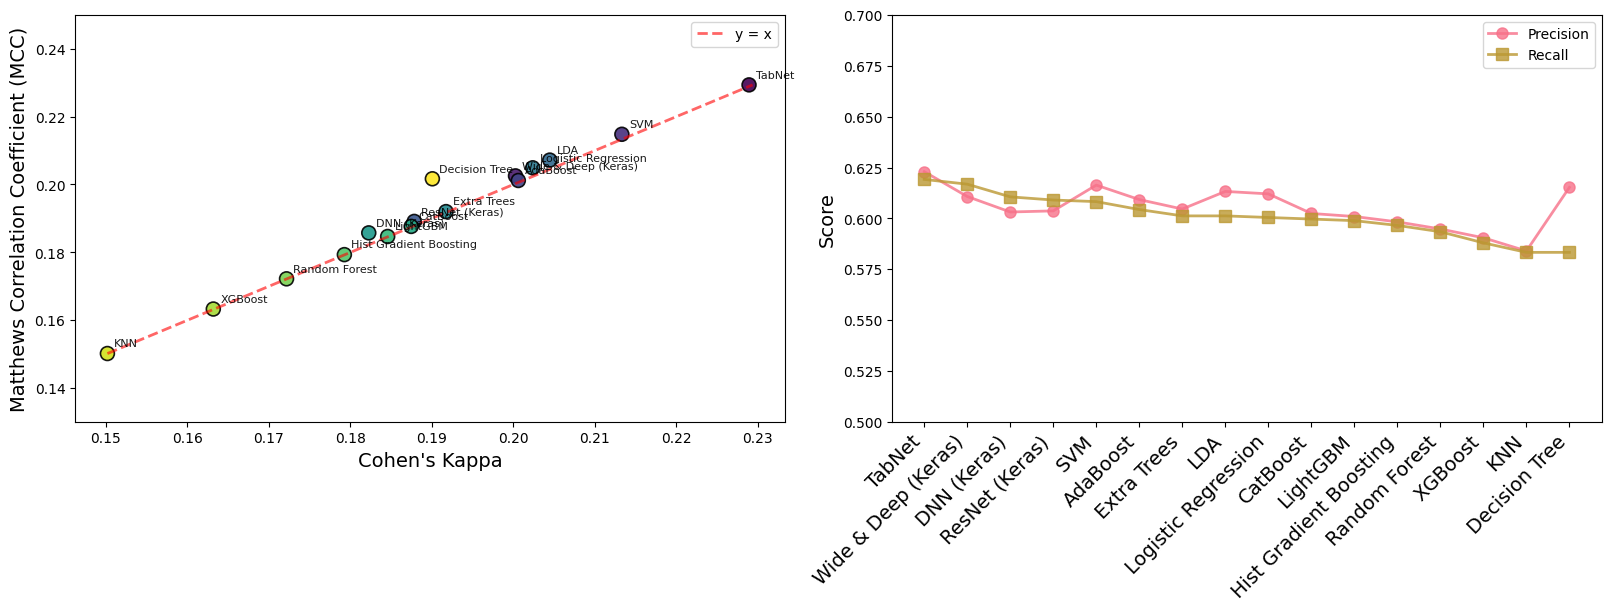

In [4]:
# ------------------------------------------------------------------
# STYLE
# ------------------------------------------------------------------
plt.style.use('default')
sns.set_palette("husl")

# ------------------------------------------------------------------
# FIGURE SETUP
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ================================================================
# PLOT 1: MCC vs Cohen's Kappa (Agreement Metrics)
# ================================================================
ax1 = axes[0]

top_10_mcc = final_df

scatter = ax1.scatter(
    top_10_mcc['Cohen Kappa'],
    top_10_mcc['MCC'],
    s=100,
    alpha=0.9,
    c=range(len(top_10_mcc)),
    cmap='viridis',
    edgecolors='black',
    linewidth=1.2
)

# Diagonal reference line
min_val = min(top_10_mcc['Cohen Kappa'].min(), top_10_mcc['MCC'].min())
max_val = max(top_10_mcc['Cohen Kappa'].max(), top_10_mcc['MCC'].max())
ax1.plot([min_val, max_val], [min_val, max_val],
         linestyle='--', linewidth=2, color='red', alpha=0.6, label='y = x')

# Annotations
for _, row in top_10_mcc.iterrows():
    ax1.annotate(
        row['Model'],
        xy=(row['Cohen Kappa'], row['MCC']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        alpha=0.9
    )

ax1.set_xlabel("Cohen's Kappa", fontsize=14)
ax1.set_ylabel("Matthews Correlation Coefficient (MCC)", fontsize=14)
# ax1.set_title("Agreement Metrics Comparison", fontsize=13)
ax1.set_ylim(0.13, 0.25)
ax1.legend()
# ax1.grid(True, alpha=0.3)

# ================================================================
# PLOT 2: Precision–Recall Trade-off
# ================================================================
ax2 = axes[1]

top_10_pr = final_df.head(18).sort_values('Recall', ascending=False)
x_pos = np.arange(len(top_10_pr))

ax2.plot(
    x_pos,
    top_10_pr['Precision'],
    marker='o',
    linewidth=2,
    markersize=8,
    label='Precision',
    alpha=0.8
)

ax2.plot(
    x_pos,
    top_10_pr['Recall'],
    marker='s',
    linewidth=2,
    markersize=8,
    label='Recall',
    alpha=0.8
)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_10_pr['Model'], rotation=45, ha='right', fontsize=14)
ax2.set_ylabel("Score", fontsize=14)
ax2.set_ylim(0.5, 0.7)
# ax2.set_title("Precision–Recall Trade-off", fontsize=13)
ax2.legend(fontsize=10)
# ax2.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# SAVE & SHOW
# ------------------------------------------------------------------
plt.savefig(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Plots\agreement_precision_recall.png", dpi=300)
plt.show()


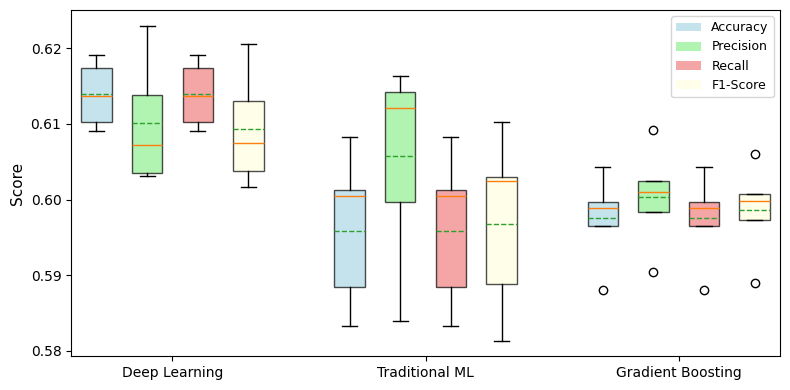

In [5]:
# ============================================================================
# PLOT 1: Within-Category Performance Variance
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(8, 4))
plt.style.use('default')

# Filter out categories with only 1 model (Attention-Based and Ensemble)
categories_to_plot = []
for cat in final_df['Category'].unique():
    cat_data = final_df[final_df['Category'] == cat]
    if len(cat_data) > 1:  # Only include categories with multiple models
        categories_to_plot.append(cat)

positions = []
data_to_plot = []
labels_list = []

for i, cat in enumerate(categories_to_plot):
    cat_data = final_df[final_df['Category'] == cat][['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    for j, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-Score']):
        positions.append(i * 5 + j)
        data_to_plot.append(cat_data[metric].values)
        if i == 0:
            labels_list.append(metric)

bp = ax1.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                showmeans=True, meanline=True)

# Color by metric
metric_colors = {'Accuracy': 'lightblue', 'Precision': 'lightgreen', 
                'Recall': 'lightcoral', 'F1-Score': 'lightyellow'}
for patch, pos in zip(bp['boxes'], positions):
    metric_idx = pos % 5
    if metric_idx < 4:
        metric_name = ['Accuracy', 'Precision', 'Recall', 'F1-Score'][metric_idx]
        patch.set_facecolor(metric_colors[metric_name])
        patch.set_alpha(0.7)

# Set labels
ax1.set_xticks([i * 5 + 1.5 for i in range(len(categories_to_plot))])
ax1.set_xticklabels(categories_to_plot)
ax1.set_ylabel('Score', fontsize=11)
# ax1.set_title('Within-Category Performance Variance', fontsize=12)
# ax1.grid(axis='y', alpha=0.3)

# Legend - Top Right Corner
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.7, label=metric) 
                  for metric, color in metric_colors.items()]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Plots\within_category_variance.png', dpi=300, bbox_inches='tight')
plt.show()

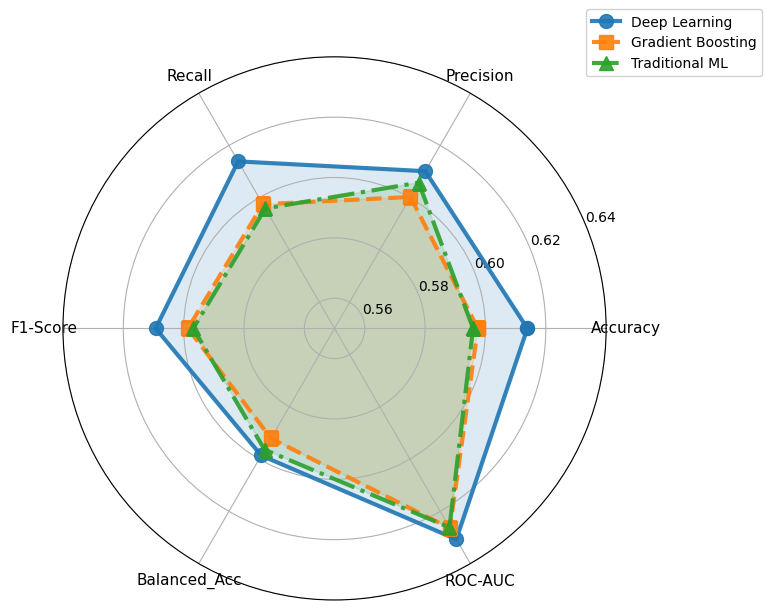

In [6]:
# ============================================================================
# PLOT 2: Performance Profile by CATEGORY (Alternative)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
plt.style.use('default')

# Aggregate by category (mean performance)
category_performance = final_df.groupby('Category')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Balanced_Acc', 'ROC-AUC']
].mean()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Balanced_Acc', 'ROC-AUC']
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

# Colors for 3 categories
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
markers = ['o', 's', '^']
linestyles = ['-', '--', '-.']

for idx, (category, row) in enumerate(category_performance.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    ax2.plot(angles, values, marker=markers[idx], linewidth=3, markersize=10, 
            label=category, color=colors_radar[idx], 
            linestyle=linestyles[idx], alpha=0.9)
    ax2.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=11)
ax2.set_ylim(0.55, 0.60)  # Adjusted for category-level comparison
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10, framealpha=0.9)

ax2.set_yticks([0.56, 0.58, 0.60, 0.62, 0.64])
ax2.set_yticklabels(['0.56', '0.58', '0.60', '0.62', '0.64'], fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Plots\performance_profile_categories.png', dpi=300, bbox_inches='tight')
plt.show()


GENERATING CALIBRATION CURVES
  ✓ SVM
  ✓ AdaBoost
  ✓ TabNet


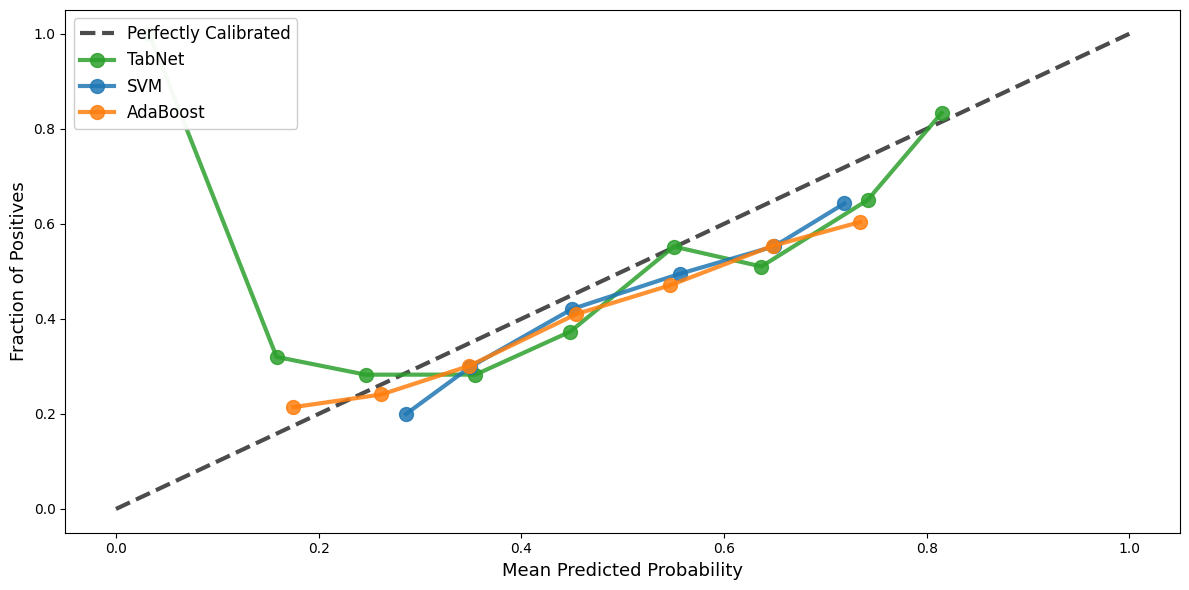

In [7]:
# ============================================================================
# CALIBRATION CURVES - SELECTED MODELS ONLY
# ============================================================================

print("\n" + "="*80)
print("GENERATING CALIBRATION CURVES")
print("="*80)
plt.style.use('default')
# Collect predictions for selected models
selected_models_predictions = {}

# SVM
try:
    X_te_svm = X_test_scaled
    y_pred_proba = traditional_models['SVM']['model'].predict_proba(X_te_svm)[:, 1]
    selected_models_predictions['SVM'] = y_pred_proba
    print("  ✓ SVM")
except Exception as e:
    print(f"  ✗ SVM: {str(e)}")

# AdaBoost
try:
    y_pred_proba = boosting_models['AdaBoost'].predict_proba(X_test)[:, 1]
    selected_models_predictions['AdaBoost'] = y_pred_proba
    print("  ✓ AdaBoost")
except Exception as e:
    print(f"  ✗ AdaBoost: {str(e)}")

# TabNet
try:
    y_pred_proba = tabnet.predict_proba(X_test_np)[:, 1]
    selected_models_predictions['TabNet'] = y_pred_proba
    print("  ✓ TabNet")
except Exception as e:
    print(f"  ✗ TabNet: {str(e)}")

# Generate calibration data
calibration_data = {}
for model_name, y_pred_proba in selected_models_predictions.items():
    try:
        fraction_of_positives, mean_predicted_value = calibration_curve(
            y_test, y_pred_proba, n_bins=10, strategy='uniform'
        )
        brier = brier_score_loss(y_test, y_pred_proba)
        
        calibration_data[model_name] = {
            'fraction_of_positives': fraction_of_positives,
            'mean_predicted_value': mean_predicted_value,
            'brier_score': brier
        }
    except Exception as e:
        print(f"  Error: {model_name}: {str(e)}")

# Plot calibration curves
fig, ax = plt.subplots(figsize=(12, 6))

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', linewidth=3, label='Perfectly Calibrated', 
        alpha=0.7, zorder=1)

# Model colors
model_colors = {
    'SVM': '#1f77b4',
    'AdaBoost': '#ff7f0e',
    'TabNet': '#2ca02c',
    'Voting Ensemble': '#d62728'
}

# Plot each model
plot_order = ['TabNet', 'SVM', 'AdaBoost']
for model_name in plot_order:
    if model_name in calibration_data:
        data = calibration_data[model_name]
        color = model_colors.get(model_name, '#000000')
        
        ax.plot(data['mean_predicted_value'], 
               data['fraction_of_positives'],
               marker='o', linewidth=3, markersize=10,
               label=f"{model_name}",
               color=color, alpha=0.85, zorder=2)

ax.set_xlabel('Mean Predicted Probability', fontsize=13)
ax.set_ylabel('Fraction of Positives', fontsize=13)
# ax.set_title('Calibration Curves: Selected Models', 
#             fontsize=16, pad=20)
ax.legend(loc='upper left', fontsize=12, framealpha=0.95)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(r'C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Rework\Plots\calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()